# 03 — Final evaluation matrix (wav2vec2-base only)

Six cells: 3 variants {pretrained, ft_noisy (Flow A), ft_enhanced (Flow B)} × 2 test conditions {raw noisy, MetricGAN+ enhanced}. All on the 824-utt VoiceBank-DEMAND test split.

**Pretrained rows are pulled from the Milestone-2 baseline CSV** — no re-inference. FT rows are computed fresh on both test conditions.

**Inputs (attach):**
- `vbd-finetune-code` — latest `train_utils.py` + `eval_utils.py`
- `vbd-labels-enhanced-train` — `transcripts.csv`
- `vbd-finetuned-noisy` — Flow A checkpoint (note `finetuned/` parent inside)
- `vbd-finetuned-enhanced` — Flow B checkpoint
- `vbd-pretrained-baselines` — `evaluation_results_wav2vec_base.csv` from local `evaluation_result_csv/`

**Output:** `/kaggle/working/eval_finetuned/` — CSVs + figures. Download and share.

In [1]:
!pip install -q transformers==4.46.* peft==0.13.* accelerate datasets jiwer pesq pystoi librosa soundfile speechbrain seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 41.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency co

In [2]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
assert torch.cuda.is_available(), 'Enable GPU T4 x2.'

CODE_PATH = '/kaggle/input/notebooks/tejaswagg/vbd-finetune-code'
if CODE_PATH not in sys.path:
    sys.path.insert(0, CODE_PATH)
import eval_utils
from eval_utils import (
    load_wav2vec2, evaluate_model_on_test, enhance_test_set, load_baseline_rows,
    compute_acoustic_metrics, attach_input_acoustic, summarize, wilcoxon_pairwise,
    fig_test_condition_heatmap, fig_wer_grouped_bars, fig_metric_radar,
    fig_wer_delta_heatmap, fig_stoi_wer_scatter, fig_noise_type_box,
    fig_acoustic_by_condition, fig_training_curves, fig_flowA_vs_flowB,
)
OUT = Path('/kaggle/working/eval_finetuned'); OUT.mkdir(exist_ok=True, parents=True)
FIG = OUT / 'figures'; FIG.mkdir(exist_ok=True)
print('eval_utils:', eval_utils.__file__)

eval_utils: /kaggle/input/notebooks/tejaswagg/vbd-finetune-code/eval_utils.py


In [3]:
TRANSCRIPTS_CSV = '/kaggle/input/datasets/tejaswagg/vbd-labels-enhanced-train/transcripts.csv'
NOISY_ROOT      = '/kaggle/input/datasets/tejaswagg/vbd-finetuned-noisy'
ENH_ROOT        = '/kaggle/input/datasets/tejaswagg/vbd-finetuned-enhanced'
BASELINE_DIR    = '/kaggle/input/datasets/tejaswagg/vdb-wav2vec2-base-result'
ENHANCED_TEST_DIR = '/kaggle/working/enhanced_test'

# auto-pick the CSV in the baseline dataset
import os
_csvs = [f for f in os.listdir(BASELINE_DIR) if f.endswith('.csv')]
assert _csvs, f'no CSV in {BASELINE_DIR}'
BASELINE_CSV = os.path.join(BASELINE_DIR, _csvs[0])
print('baseline csv:', BASELINE_CSV)

for p in [TRANSCRIPTS_CSV, BASELINE_CSV]:
    assert os.path.exists(p), f'Missing input: {p}'
print('inputs present')

baseline csv: /kaggle/input/datasets/tejaswagg/vdb-wav2vec2-base-result/evaluation_results.csv
inputs present


In [4]:
from datasets import load_dataset
test_ds = load_dataset('JacobLinCool/VoiceBank-DEMAND-16k', split='test')
tr = pd.read_csv(TRANSCRIPTS_CSV)
transcripts = dict(zip(tr[tr['split']=='test']['id'], tr[tr['split']=='test']['text'].astype(str)))
print('test samples:', len(test_ds), '| transcripts:', len(transcripts))

README.md:   0%|          | 0.00/652 [00:00<?, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/444M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/431M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/444M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/132M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11572 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/824 [00:00<?, ? examples/s]

test samples: 824 | transcripts: 824


## 1. Enhance the test set with MetricGAN+
Cached to `/kaggle/working/enhanced_test/` — re-runs are no-ops if files exist.

In [5]:
enhance_test_set(test_ds, ENHANCED_TEST_DIR)
n_wavs = sum(1 for _ in os.scandir(ENHANCED_TEST_DIR) if _.name.endswith('.wav'))
print('enhanced test wavs:', n_wavs)

hyperparams.yaml: 0.00B [00:00, ?B/s]

enhance_model.ckpt:   0%|          | 0.00/7.59M [00:00<?, ?B/s]

Could not parse CUDA device string 'cuda': not enough values to unpack (expected 2, got 1). Falling back to device 0.


  enhance: 100/824
  enhance: 200/824
  enhance: 300/824
  enhance: 400/824
  enhance: 500/824
  enhance: 600/824
  enhance: 700/824
  enhance: 800/824
enhanced test wavs: 824


## 2. Acoustic metrics (PESQ/STOI of noisy input vs clean)
Per-utt, independent of any ASR model. Attached to every per-utt row.

In [6]:
acoustic = compute_acoustic_metrics(test_ds, enhanced_dir=ENHANCED_TEST_DIR)
acoustic.to_csv(OUT/'acoustic_metrics.csv', index=False)
print(acoustic.describe())

  acoustic: 100/824
  acoustic: 200/824
  acoustic: 300/824
  acoustic: 400/824
  acoustic: 500/824
  acoustic: 600/824
  acoustic: 700/824
  acoustic: 800/824
       pesq_noisy  stoi_noisy  pesq_enhanced  stoi_enhanced
count  824.000000  824.000000     824.000000     824.000000
mean     1.970677    0.921013       3.133226       0.931648
std      0.754146    0.070955       0.557157       0.057874
min      1.030891    0.561137       1.535252       0.602014
25%      1.290184    0.887732       2.741388       0.901714
50%      1.800505    0.939690       3.184386       0.949273
75%      2.552828    0.975459       3.578118       0.975532
max      4.307923    0.999815       4.433107       0.997771


## 3. Pretrained baseline rows from the Milestone-2 CSV
No inference — just reshape the existing CSV into long format with `test_audio ∈ {noisy, enhanced}`.

In [7]:
baseline_rows = load_baseline_rows(BASELINE_CSV, model_name='wav2vec2-base')
print('baseline rows:', len(baseline_rows))
print(baseline_rows.groupby(['variant','test_audio'])['wer'].mean())

baseline rows: 1648
variant     test_audio
pretrained  enhanced      0.117604
            noisy         0.127381
Name: wer, dtype: float64


## 4. Run inference for each FT checkpoint × test condition
4 passes total: {Flow A, Flow B} × {noisy, enhanced}. ~3 min each on T4.

In [8]:
def find_ckpt(root, model_key='wav2vec2_base'):
    p = Path(root)
    if not p.exists():
        return None
    matches = [d for d in p.rglob('*') if d.is_dir() and model_key in d.name]
    matches.sort(key=lambda d: len(str(d)), reverse=True)
    for d in matches:
        if (d/'config.json').exists() or (d/'adapter_config.json').exists():
            return str(d)
    return None

ckpts = {
    'ft_noisy':    find_ckpt(NOISY_ROOT),
    'ft_enhanced': find_ckpt(ENH_ROOT),
}
for k, v in ckpts.items():
    print(k, '->', v)
    assert v, f'No wav2vec2 checkpoint found under {k}'

ft_noisy -> /kaggle/input/datasets/tejaswagg/vbd-finetuned-noisy/finetuned/noisy/wav2vec2_base_full
ft_enhanced -> /kaggle/input/datasets/tejaswagg/vbd-finetuned-enhanced/finetuned/enhanced/wav2vec2_base_full


In [9]:
frames = [baseline_rows]
for variant, ckpt in ckpts.items():
    print(f'\n>> Loading {variant}: {ckpt}')
    model, processor = load_wav2vec2(ckpt)
    for audio_source in ['noisy', 'enhanced']:
        print(f'   inference: test_audio={audio_source}')
        df = evaluate_model_on_test(
            model, processor, 'wav2vec2', test_ds, transcripts,
            variant_name=variant, model_name='wav2vec2-base',
            audio_source=audio_source,
            enhanced_dir=ENHANCED_TEST_DIR if audio_source == 'enhanced' else None,
        )
        frames.append(df)
    del model, processor; torch.cuda.empty_cache()

per_utt = pd.concat(frames, ignore_index=True)
stale = [c for c in ['pesq_noisy','stoi_noisy','pesq_enhanced','stoi_enhanced'] if c in per_utt.columns]
per_utt = per_utt.drop(columns=stale)
per_utt = per_utt.merge(acoustic, on='id', how='left')
per_utt = attach_input_acoustic(per_utt)
per_utt.to_csv(OUT/'per_utterance_results.csv', index=False)
print('\ntotal rows:', len(per_utt))
print(per_utt.groupby(['variant','test_audio'])['wer'].agg(['count','mean']).round(4))
print('\ninput acoustic by test_audio:')
print(per_utt.groupby('test_audio')[['pesq_input','stoi_input']].mean().round(3))


>> Loading ft_noisy: /kaggle/input/datasets/tejaswagg/vbd-finetuned-noisy/finetuned/noisy/wav2vec2_base_full


0it [00:00, ?it/s]

2026-06-24 06:54:24.892016: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782284065.108380      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782284065.177058      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782284065.728672      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782284065.728711      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782284065.728714      23 computation_placer.cc:177] computation placer alr

   inference: test_audio=noisy
  ft_noisy/wav2vec2-base/noisy: 200/824
  ft_noisy/wav2vec2-base/noisy: 400/824
  ft_noisy/wav2vec2-base/noisy: 600/824
  ft_noisy/wav2vec2-base/noisy: 800/824
   inference: test_audio=enhanced
  ft_noisy/wav2vec2-base/enhanced: 200/824
  ft_noisy/wav2vec2-base/enhanced: 400/824
  ft_noisy/wav2vec2-base/enhanced: 600/824
  ft_noisy/wav2vec2-base/enhanced: 800/824

>> Loading ft_enhanced: /kaggle/input/datasets/tejaswagg/vbd-finetuned-enhanced/finetuned/enhanced/wav2vec2_base_full
   inference: test_audio=noisy
  ft_enhanced/wav2vec2-base/noisy: 200/824
  ft_enhanced/wav2vec2-base/noisy: 400/824
  ft_enhanced/wav2vec2-base/noisy: 600/824
  ft_enhanced/wav2vec2-base/noisy: 800/824
   inference: test_audio=enhanced
  ft_enhanced/wav2vec2-base/enhanced: 200/824
  ft_enhanced/wav2vec2-base/enhanced: 400/824
  ft_enhanced/wav2vec2-base/enhanced: 600/824
  ft_enhanced/wav2vec2-base/enhanced: 800/824

total rows: 4944
                        count    mean
variant

## 5. Summary, Wilcoxon, per-noise breakdown

In [10]:
summary = summarize(per_utt)
summary.to_csv(OUT/'summary_means.csv', index=False)
summary[summary['metric']=='wer']

,model,variant,test_audio,metric,mean,ci_lo,ci_hi,n
0,wav2vec2-base,ft_enhanced,enhanced,wer,0.084077,0.073312,0.095629,824
8,wav2vec2-base,ft_enhanced,noisy,wer,0.097304,0.085343,0.110013,824
16,wav2vec2-base,ft_noisy,enhanced,wer,0.092893,0.081709,0.104256,824
24,wav2vec2-base,ft_noisy,noisy,wer,0.087997,0.076809,0.099395,824
32,wav2vec2-base,pretrained,enhanced,wer,0.117604,0.103536,0.131423,824
40,wav2vec2-base,pretrained,noisy,wer,0.127381,0.112964,0.142612,824


In [11]:
wlx_wer  = wilcoxon_pairwise(per_utt, metric='wer')
wlx_pesq = wilcoxon_pairwise(per_utt, metric='pesq_input')
wlx_stoi = wilcoxon_pairwise(per_utt, metric='stoi_input')
wlx = pd.concat([wlx_wer, wlx_pesq, wlx_stoi], ignore_index=True)
wlx.to_csv(OUT/'wilcoxon_pairwise.csv', index=False)
wlx

,comparison,model,test_audio,a,b,metric,mean_a,mean_b,delta,wilcoxon_stat,p_value,n
0,variant,wav2vec2-base,enhanced,pretrained,ft_noisy,wer,0.117604,0.092893,-0.024711,142033.0,3.109160e-05,824
1,variant,wav2vec2-base,enhanced,pretrained,ft_enhanced,wer,0.117604,0.084077,-0.033527,129194.0,1.188566e-09,824
2,variant,wav2vec2-base,enhanced,ft_noisy,ft_enhanced,wer,0.092893,0.084077,-0.008816,152333.5,5.701577e-03,824
3,variant,wav2vec2-base,noisy,pretrained,ft_noisy,wer,0.127381,0.087997,-0.039384,135953.0,3.855525e-07,824
4,variant,wav2vec2-base,noisy,pretrained,ft_enhanced,wer,0.127381,0.097304,-0.030077,139132.0,4.120975e-06,824
5,variant,wav2vec2-base,noisy,ft_noisy,ft_enhanced,wer,0.087997,0.097304,0.009307,158874.5,8.392865e-02,824
6,test_audio,wav2vec2-base,noisy_vs_enhanced,ft_enhanced/noisy,ft_enhanced/enhanced,wer,0.097304,0.084077,-0.013227,151530.5,4.060093e-03,824
7,test_audio,wav2vec2-base,noisy_vs_enhanced,ft_noisy/noisy,ft_noisy/enhanced,wer,0.087997,0.092893,0.004896,166787.0,6.197635e-01,824
8,test_audio,wav2vec2-base,noisy_vs_enhanced,pretrained/noisy,pretrained/enhanced,wer,0.127381,0.117604,-0.009777,160640.0,1.560976e-01,824
9,variant,wav2vec2-base,enhanced,pretrained,ft_noisy,pesq_input,3.133226,3.133226,0.000000,169950.0,1.000000e+00,824


In [12]:
# Override id-parse noise_type with the HF dataset's noise_type column when available.
sample0 = test_ds[0]
hf_noise_col = 'noise_type' if 'noise_type' in sample0 else None
if hf_noise_col:
    meta = pd.DataFrame([{'id': s['id'], 'noise_type_hf': s[hf_noise_col]} for s in test_ds])
    per_utt = per_utt.merge(meta, on='id', how='left')
    per_utt['noise_type'] = per_utt['noise_type_hf'].fillna(per_utt['noise_type'])
    per_utt = per_utt.drop(columns=['noise_type_hf'])
    per_utt.to_csv(OUT/'per_utterance_results.csv', index=False)
    print('noise_type sourced from HF column')
else:
    print('HF dataset has no noise_type column; using id-parse fallback')

noise_break = per_utt.groupby(['variant','test_audio','noise_type'])[['wer','cer']].mean().reset_index()
noise_break.to_csv(OUT/'noise_type_breakdown.csv', index=False)
print(noise_break.head(20))

HF dataset has no noise_type column; using id-parse fallback
       variant test_audio noise_type       wer       cer
0  ft_enhanced   enhanced    unknown  0.084077  0.033049
1  ft_enhanced      noisy    unknown  0.097304  0.044660
2     ft_noisy   enhanced    unknown  0.092893  0.038927
3     ft_noisy      noisy    unknown  0.087997  0.035261
4   pretrained   enhanced    unknown  0.117604  0.049690
5   pretrained      noisy    unknown  0.127381  0.057598


## 6. Figures

In [13]:
fig_test_condition_heatmap(per_utt, str(FIG/'test_condition_heatmap.png'))
fig_acoustic_by_condition(per_utt, str(FIG/'acoustic_by_condition.png'))

noisy_only = per_utt[per_utt['test_audio']=='noisy']
fig_wer_grouped_bars (noisy_only, str(FIG/'wer_grouped_bars_noisy.png'))
fig_wer_delta_heatmap(noisy_only, str(FIG/'wer_delta_heatmap_noisy.png'))
fig_stoi_wer_scatter (noisy_only, str(FIG/'stoi_wer_scatter_noisy.png'))
fig_noise_type_box   (noisy_only, str(FIG/'noise_type_box_noisy.png'))
fig_metric_radar     (noisy_only, str(FIG/'metric_radar_noisy.png'))
fig_flowA_vs_flowB   (noisy_only, str(FIG/'flowA_vs_flowB_noisy.png'))

enh_only = per_utt[per_utt['test_audio']=='enhanced']
fig_wer_grouped_bars (enh_only, str(FIG/'wer_grouped_bars_enhanced.png'))
fig_stoi_wer_scatter (enh_only, str(FIG/'stoi_wer_scatter_enhanced.png'))
fig_metric_radar     (enh_only, str(FIG/'metric_radar_enhanced.png'))
fig_flowA_vs_flowB   (enh_only, str(FIG/'flowA_vs_flowB_enhanced.png'))

log_paths = {}
for root in [NOISY_ROOT, ENH_ROOT]:
    for log in Path(root).rglob('train_log.jsonl'):
        log_paths[f'{Path(root).name}/{log.parent.name}'] = str(log)
if log_paths:
    fig_training_curves(log_paths, str(FIG/'training_curves.png'))

for p in sorted(FIG.iterdir()):
    print(' ', p.name)

/kaggle/input/notebooks/tejaswagg/vbd-finetune-code/eval_utils.py:398: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cells = refs.apply(lambda g: compute_wer(g["ref"].tolist(), g["hyp"].tolist())


  acoustic_by_condition.png
  flowA_vs_flowB_enhanced.png
  flowA_vs_flowB_noisy.png
  metric_radar_enhanced.png
  metric_radar_noisy.png
  noise_type_box_noisy.png
  stoi_wer_scatter_enhanced.png
  stoi_wer_scatter_noisy.png
  test_condition_heatmap.png
  training_curves.png
  wer_delta_heatmap_noisy.png
  wer_grouped_bars_enhanced.png
  wer_grouped_bars_noisy.png


## 7. Comparator markdown table for the report

In [14]:
from jiwer import wer as compute_wer
rows = []
for (variant, ta), sub in per_utt.groupby(['variant','test_audio']):
    rows.append({
        'variant': variant, 'test_audio': ta,
        'n': len(sub),
        'corpus_wer': compute_wer(sub['ref'].tolist(), sub['hyp'].tolist()),
        'mean_wer':   sub['wer'].mean(),
        'median_wer': sub['wer'].median(),
        'mean_cer':   sub['cer'].mean(),
        'mean_pesq':  sub['pesq_input'].mean() if 'pesq_input' in sub else float('nan'),
        'mean_stoi':  sub['stoi_input'].mean() if 'stoi_input' in sub else float('nan'),
    })
comp = pd.DataFrame(rows).sort_values(['variant','test_audio']).round(4)
comp.to_csv(OUT/'comparator_table.csv', index=False)
md = comp.to_markdown(index=False)
(OUT/'comparator_table.md').write_text(md)
print(md)

| variant     | test_audio   |   n |   corpus_wer |   mean_wer |   median_wer |   mean_cer |   mean_pesq |   mean_stoi |
|:------------|:-------------|----:|-------------:|-----------:|-------------:|-----------:|------------:|------------:|
| ft_enhanced | enhanced     | 824 |       0.0772 |     0.0841 |            0 |     0.033  |      3.1332 |      0.9316 |
| ft_enhanced | noisy        | 824 |       0.0933 |     0.0973 |            0 |     0.0447 |      1.9707 |      0.921  |
| ft_noisy    | enhanced     | 824 |       0.0872 |     0.0929 |            0 |     0.0389 |      3.1332 |      0.9316 |
| ft_noisy    | noisy        | 824 |       0.083  |     0.088  |            0 |     0.0353 |      1.9707 |      0.921  |
| pretrained  | enhanced     | 824 |       0.1094 |     0.1176 |            0 |     0.0497 |      3.1332 |      0.9316 |
| pretrained  | noisy        | 824 |       0.1179 |     0.1274 |            0 |     0.0576 |      1.9707 |      0.921  |


--- test_condition_heatmap.png


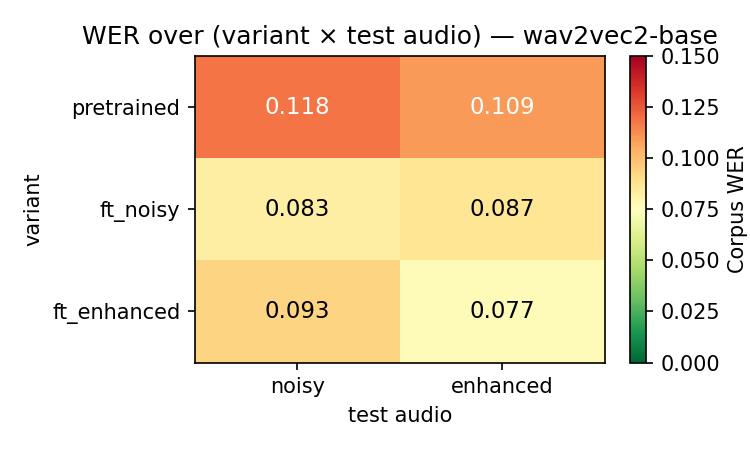

--- wer_grouped_bars_noisy.png


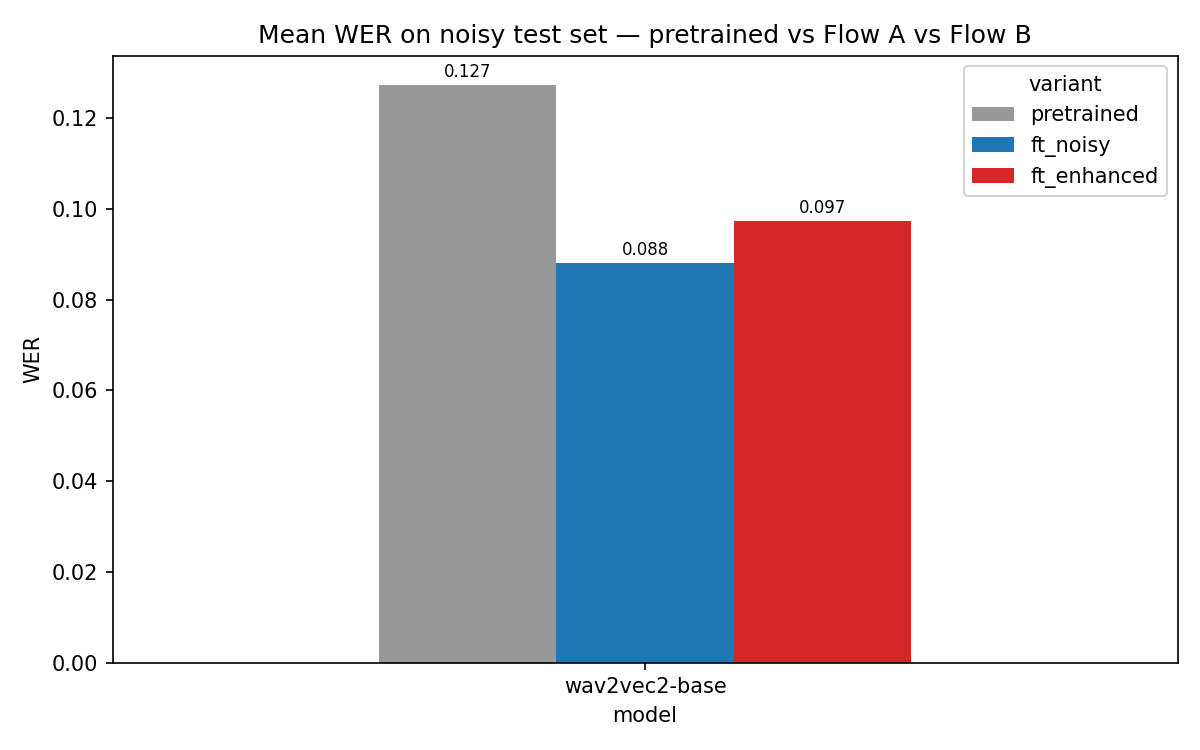

--- wer_delta_heatmap_noisy.png


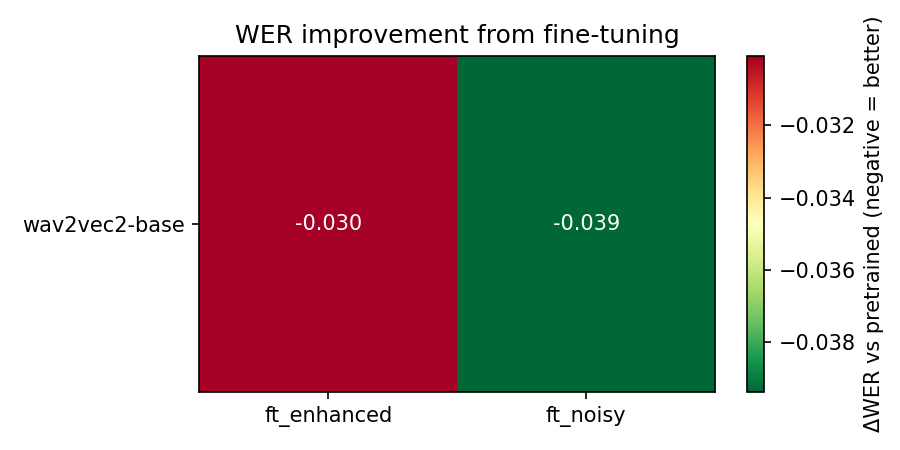

--- flowA_vs_flowB_noisy.png


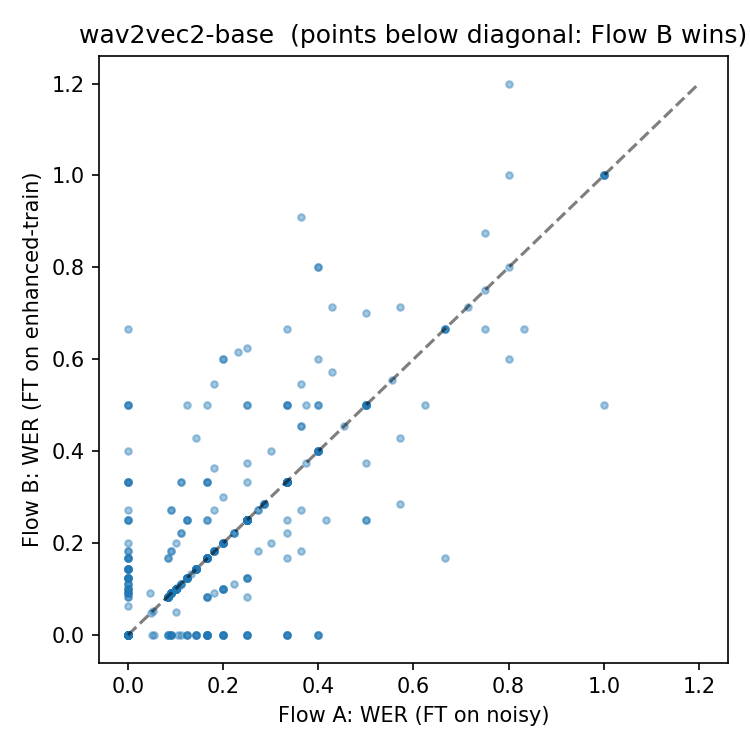

--- metric_radar_noisy.png


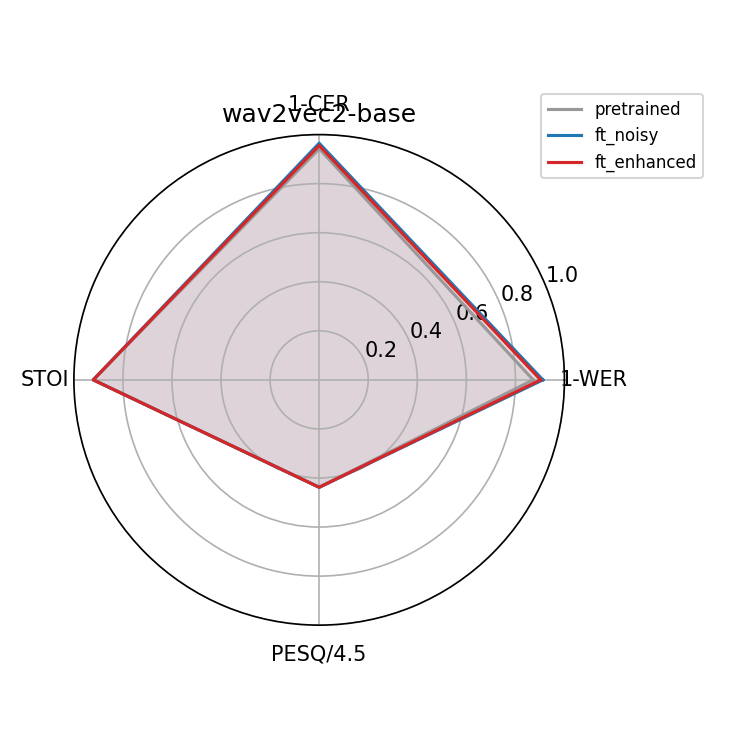

--- noise_type_box_noisy.png


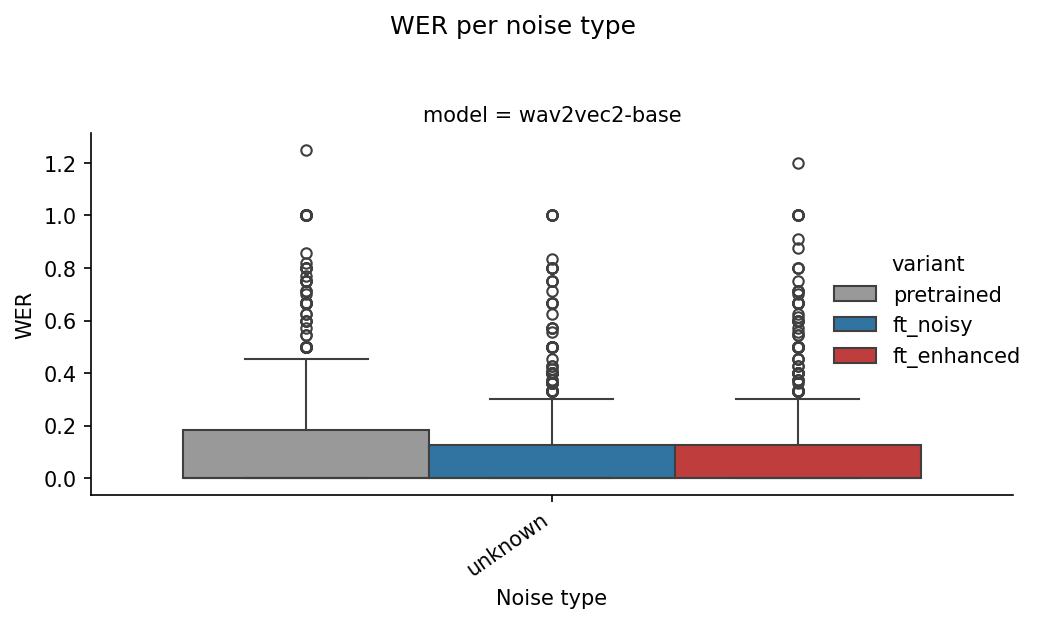

In [15]:
from IPython.display import Image, display
for name in ['test_condition_heatmap.png', 'wer_grouped_bars_noisy.png',
             'wer_delta_heatmap_noisy.png', 'flowA_vs_flowB_noisy.png',
             'metric_radar_noisy.png', 'noise_type_box_noisy.png']:
    p = FIG/name
    if p.exists():
        print('---', name); display(Image(str(p)))

In [16]:
import shutil
archive = shutil.make_archive('/kaggle/working/eval_finetuned_results', 'zip',
                              str(OUT.parent), OUT.name)
print('archive:', archive, '\nfiles in eval_finetuned/:')
for p in sorted(OUT.rglob('*')):
    if p.is_file():
        print(' ', p.relative_to(OUT), p.stat().st_size, 'B')

archive: /kaggle/working/eval_finetuned_results.zip 
files in eval_finetuned/:
  acoustic_metrics.csv 69170 B
  comparator_table.csv 442 B
  comparator_table.md 967 B
  figures/acoustic_by_condition.png 35745 B
  figures/flowA_vs_flowB_enhanced.png 59880 B
  figures/flowA_vs_flowB_noisy.png 60968 B
  figures/metric_radar_enhanced.png 100035 B
  figures/metric_radar_noisy.png 99183 B
  figures/noise_type_box_noisy.png 47876 B
  figures/stoi_wer_scatter_enhanced.png 94472 B
  figures/stoi_wer_scatter_noisy.png 93845 B
  figures/test_condition_heatmap.png 49570 B
  figures/training_curves.png 108422 B
  figures/wer_delta_heatmap_noisy.png 38611 B
  figures/wer_grouped_bars_enhanced.png 44955 B
  figures/wer_grouped_bars_noisy.png 44975 B
  noise_type_breakdown.csv 438 B
  per_utterance_results.csv 1266548 B
  summary_means.csv 5015 B
  wilcoxon_pairwise.csv 4050 B


## Done
Download `eval_finetuned_results.zip` from the Kaggle Output panel and drop it locally. Share back to generate the Milestone-3 report.